In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import load_model

In [14]:
print("Current working directory:", os.getcwd())
print("Files in this directory:", os.listdir())

Current working directory: /content
Files in this directory: ['.config', 'drive', 'cat_breed_model_v9.keras', 'sample_data']


In [15]:
cat_dog_model = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/Cat_Dog_breed_classifier/Combined models/cats_dogs_classifier_trained_model.h5")
cat_breed_model = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/Cat_Dog_breed_classifier/Combined models/cat_breed_model_v9.keras")
dog_breed_model = tf.keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/Cat_Dog_breed_classifier/Combined models/dog_breed_model_tuned.keras")

In [16]:
cat_breeds = [
    "Abyssinian",
    "Bengal",
    "Birman",
    "Bombay",
    "British Shorthair",
    "Egyptian Mau",
    "Maine Coon",
    "Persian",
    "Ragdoll",
    "Russian Blue",
    "Siamese",
    "Sphynx"
]

dog_breeds = [
    "American Bulldog",
    "American Pit Bull Terrier",
    "Basset Hound",
    "Beagle",
    "Boxer",
    "Chihuahua",
    "English Cocker Spaniel",
    "English Setter",
    "German Shorthaired",
    "Great Pyrenees",
    "Havanese",
    "Japanese Chin",
    "Keeshond",
    "Leonberger",
    "Miniature Pinscher",
    "Newfoundland",
    "Pomeranian",
    "Pug",
    "Saint Bernard",
    "Samoyed",
    "Scottish Terrier",
    "Shiba Inu",
    "Staffordshire Bull Terrier",
    "Wheaten Terrier",
    "Yorkshire Terrier"
]

In [17]:
def load_and_prepare(img_path):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img224 = cv2.resize(img, (224,224))
    img224 = img224.astype("float32") / 255.0
    img224 = np.expand_dims(img224, axis=0)

    img225 = cv2.resize(img, (225,225))
    img225 = img225.astype("float32") / 255.0
    img225 = np.expand_dims(img225, axis=0)

    return img224, img225

In [68]:
def predict_animal(image):
    prediction = cat_dog_model.predict(image)
    if prediction[0][0] > 0.5:
        return "Dog"
    else:
        return "Cat"

In [69]:
def predict_breed(image224, image225):

    animal = predict_animal(image224)

    if animal == "Cat":
        breed_pred = cat_breed_model.predict(image225)
        breed_index = np.argmax(breed_pred)
        breed = cat_breeds[breed_index]

    else:
        breed_pred = dog_breed_model.predict(image225)
        breed_index = np.argmax(breed_pred)
        breed = dog_breeds[breed_index]

    return animal, breed

In [70]:
print("Expected input shape:", cat_dog_model.input_shape)
print("Expected input shape:", cat_breed_model.input_shape)
print("Expected input shape:", dog_breed_model.input_shape)

Expected input shape: (None, 224, 224, 3)
Expected input shape: (None, 225, 225, 3)
Expected input shape: (None, 224, 224, 3)


In [71]:
image_path = "/content/drive/MyDrive/Colab Notebooks/Cat_Dog_breed_classifier/Combined models/test_image_6.jpg"

image224, image225 = load_and_prepare(image_path)

animal, breed = predict_breed(image224, image225)

print("Animal:", animal)
print("Breed:", breed)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
Animal: Cat
Breed: Russian Blue


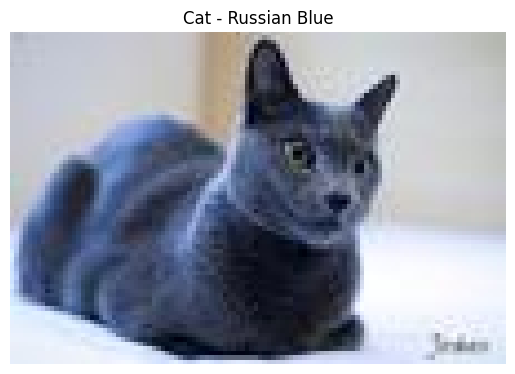

In [72]:
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(f"{animal} - {breed}")
plt.axis("off")
plt.show()